In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix
import torch

In [4]:
import pandas as pd
import os

# 1. Define the exact path the error gave us
target_dir = r"C:\Users\vivek\python projects\project-2-sentiment-analysis\data"
target_file = os.path.join(target_dir, "slang_reviews.csv")

# 2. Create the folder if it's missing
if not os.path.exists(target_dir):
    os.makedirs(target_dir)
    print(f"Created folder at: {target_dir}")
# 3. Define the data
data = {
    "text": [
        "This movie was absolutely fire! 🔥 best CGI ever.",
        "The plot was mid, honestly expected more from the director.",
        "Total masterpiece, 10/10 would watch again.",
        "Literally the worst thing I've seen all year. Noob acting.",
        "That final battle was GOAT level. Absolute peak cinema.",
        "Cringe acting and boring story. Don't waste your time.",
        "The protagonist was such a mood, loved every second.",
        "Mid-tier flick at best. Not worth the hype.",
        "Pure gas! The soundtrack goes so hard.",
        "I was shook by the ending. Best plot twist of 2025.",
        "Trash movie. The script felt like it was written by AI.",
        "Obsessed with the visuals. A literal aesthetic dream.",
        "Dead 💀 this comedy is actually hilarious.",
        "Main character is a whole L. So annoying.",
        "The pacing was a bit slow, but the ending slapped.",
        "Big yikes for the special effects. Looked like a PS2 game.",
        "Slays every scene. A must-watch for everyone.",
        "This is it. The high point of the franchise. No cap.",
        "Lowkey boring, but the lead actor is cute.",
        "Bruh, what was that ending? So confused and disappointed.",
        "Ate and left no crumbs. Iconic performance! 💅",
        "This movie fell off so hard after the first 20 minutes.",
        "Actually living for this cinematography. Pure vibes.",
        "The villain was so basic. Zero depth, zero aura.",
        "Straight bussin! Best horror movie in years.",
        "I’m crying at how bad this was. 🤡 an absolute joke.",
        "Rent free! This story is going to stay in my head forever.",
        "W movie. Finally a sequel that doesn't suck.",
        "It was giving... nothing. Just a total skip.",
        "The chemistry between the leads was non-existent. Boring.",
        "Screaming! That jump scare actually got me. 😱",
        "It’s a no from me. Total flop.",
        "Everything about this is top tier. Chefs kiss. 👨‍🍳",
        "This movie is a fever dream, but in a good way?",
        "Don't believe the bots, this movie is actual garbage.",
        "The animation is cracked! Unbelievable detail.",
        "I fell asleep twice. Snoozefest 😴",
        "Highkey the best animated film since Spider-Verse.",
        "The ending was a total letdown. Ruined the whole vibe.",
        "Valid. Not a 10/10 but definitely worth a watch.",
        "They really thought they did something... they did not.",
        "Iconic. Revolutionary. A total serve.",
        "The CGI was sus. Some parts looked unfinished.",
        "I'm salty I paid money for this ticket. 🧂",
        "A whole masterpiece. No notes. Just perfect.",
        "The plot holes are massive. Make it make sense!",
        "Vibe check passed. Perfect Saturday night movie.",
        "So hyped for this but it was a total L.",
        "Goated director. He literally never misses.",
        "It’s mid. Not bad, but I’ve seen better on TikTok."
    ],
    "label": [1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 
              1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 
              0, 1, 0, 0, 1, 0, 1, 0, 1, 0]
}

# 4. Save and Verify
df = pd.DataFrame(data)
df.to_csv(target_file, index=False)

if os.path.exists(target_file):
    print(f"✅ SUCCESS! File created at: {target_file}")
    # Now try to load it
    df_loaded = pd.read_csv(target_file)
    display(df_loaded.head())
else:
    print("❌ Critical Error: System denied file creation.")

✅ SUCCESS! File created at: C:\Users\vivek\python projects\project-2-sentiment-analysis\data\slang_reviews.csv


,text,label
0,This movie was absolutely fire! 🔥 best CGI ever.,1
1,"The plot was mid, honestly expected more from ...",0
2,"Total masterpiece, 10/10 would watch again.",1
3,Literally the worst thing I've seen all year. ...,0
4,That final battle was GOAT level. Absolute pea...,1


In [5]:
try:
    df = pd.read_csv("../data/slang_reviews.csv")
    print(" Dataset loaded successfully")
    display(df.head())
except FileNotFoundError:
    print(" CSV not found. Ensure it is in the /data folder.")

 Dataset loaded successfully


,text,label
0,This movie was absolutely fire! 🔥 best CGI ever.,1
1,"The plot was mid, honestly expected more from ...",0
2,"Total masterpiece, 10/10 would watch again.",1
3,Literally the worst thing I've seen all year. ...,0
4,That final battle was GOAT level. Absolute pea...,1


C:\Users\vivek\AppData\Local\Temp\ipykernel_572\2075590706.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='viridis')


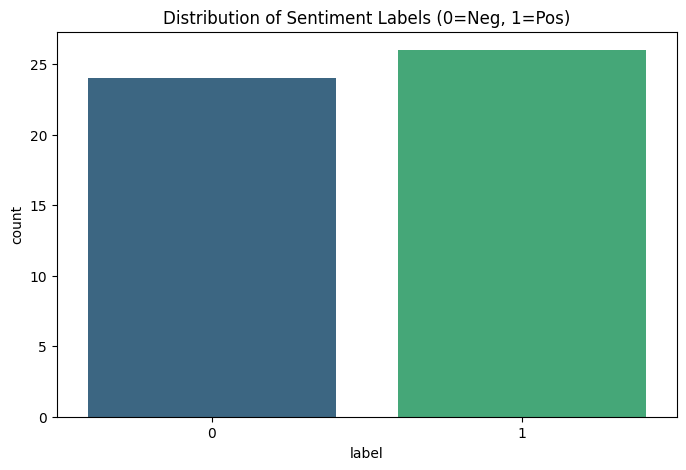

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='viridis')
plt.title("Distribution of Sentiment Labels (0=Neg, 1=Pos)")
plt.show()

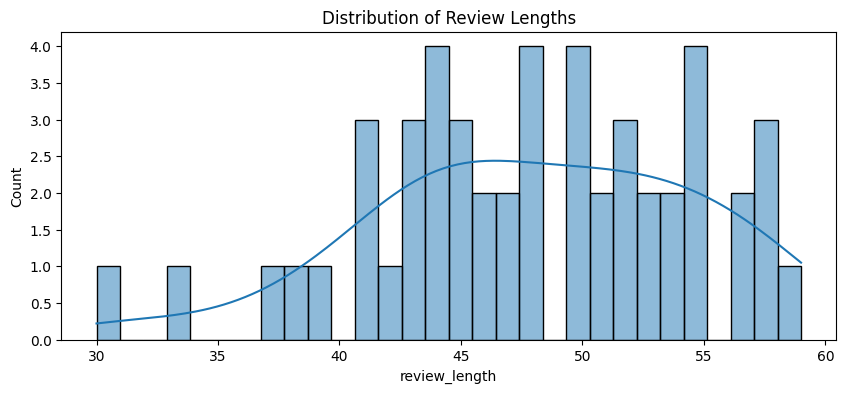

In [7]:
df['review_length'] = df['text'].apply(len)
plt.figure(figsize=(10, 4))
sns.histplot(df['review_length'], bins=30, kde=True)
plt.title("Distribution of Review Lengths")
plt.show()

In [11]:
import torch
from transformers import pipeline

model_name = "distilbert-base-uncased-finetuned-sst-2-english"

# Explicitly setting framework="pt" forces a clean PyTorch initialization pass
classifier = pipeline("sentiment-analysis", model=model_name, framework="pt")

Device set to use cpu


In [9]:
sample_df = df.sample(min(50, len(df)))
texts = sample_df['text'].tolist()
actuals = sample_df['label'].tolist()

# Run Inference
results = classifier(texts, truncation=True)
preds = [1 if r['label'] == 'POSITIVE' else 0 for r in results]


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.96      0.88        24
           1       0.95      0.81      0.88        26

    accuracy                           0.88        50
   macro avg       0.89      0.88      0.88        50
weighted avg       0.89      0.88      0.88        50



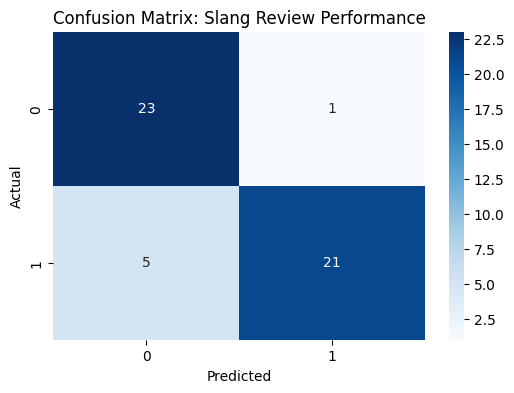

In [10]:
print("\n--- Classification Report ---")
print(classification_report(actuals, preds))

# Plotting the Confusion Matrix
cm = confusion_matrix(actuals, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: Slang Review Performance')
plt.show()